# 🪙 Bitcoin Price Analysis & Forecasting
### Time Series Forecasting + Unsupervised Machine Learning

---

**Objectives:**
- Load and preprocess Bitcoin OHLCV data
- Resample to multiple time frequencies
- Apply Box-Cox transformation and SARIMAX forecasting
- Engineer features for ML
- Cluster market regimes using **KMeans** and **DBSCAN**
- Evaluate and visualize all results

---

## 1. Imports & Configuration

In [30]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import warnings
from itertools import product

# ML
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import pickle
import os

warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9f9f9',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        12
})

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


---
## 2. Data Loading & Preparation

In [31]:
def load_and_prepare_data(file_path):
    """
    Load raw BTC CSV, parse timestamps, rename columns,
    sort chronologically, and compute a Weighted Price.
    """
    df = pd.read_csv(file_path)

    # Parse Unix timestamp
    if 'Timestamp' in df.columns:
        df['Date'] = pd.to_datetime(df['Timestamp'], unit='s')
        df.drop(columns=['Timestamp'], inplace=True)

    # Standardise column names
    df.rename(columns={
        'open':   'Open',
        'high':   'High',
        'low':    'Low',
        'close':  'Close',
        'volume': 'Volume_(BTC)'
    }, inplace=True)

    df.sort_values('Date', inplace=True)

    # Weighted price = average of OHLC
    df['Weighted_Price'] = (df['Open'] + df['High'] + df['Low'] + df['Close']) / 4

    df.set_index('Date', inplace=True)

    return df


# ── Change this path to your local CSV ──
FILE_PATH = r"C:\Users\osama\OneDrive\Documents\FAI\Python Projects\Level 3\Applied Machine Learning\Project1\Applied Machine Project\archive\btcusd_1-min_data.csv"
df = load_and_prepare_data(FILE_PATH)

print(f'Shape : {df.shape}')
print(f'Period: {df.index.min()}  →  {df.index.max()}')
df.head()

Shape : (7556814, 6)
Period: 2012-01-01 10:01:00  →  2026-05-16 00:14:00


,Open,High,Low,Close,Volume,Weighted_Price
Date,,,,,,
2012-01-01 10:01:00,4.58,4.58,4.58,4.58,0.0,4.58
2012-01-01 10:02:00,4.58,4.58,4.58,4.58,0.0,4.58
2012-01-01 10:03:00,4.58,4.58,4.58,4.58,0.0,4.58
2012-01-01 10:04:00,4.58,4.58,4.58,4.58,0.0,4.58
2012-01-01 10:05:00,4.58,4.58,4.58,4.58,0.0,4.58


---
## 3. Resampling

In [32]:
def resample_data(df):
    """
    Aggregate 1-min data to Daily / Monthly / Quarterly / Yearly
    using mean aggregation.
    """
    df_daily     = df.resample('D').mean()
    df_monthly   = df.resample('ME').mean()
    df_quarterly = df.resample('QE-DEC').mean()
    df_yearly    = df.resample('YE-DEC').mean()

    print('Resampled counts:')
    print(f'  Daily     : {len(df_daily):>5} rows')
    print(f'  Monthly   : {len(df_monthly):>5} rows')
    print(f'  Quarterly : {len(df_quarterly):>5} rows')
    print(f'  Yearly    : {len(df_yearly):>5} rows')

    return df_daily, df_monthly, df_quarterly, df_yearly


df_daily, df_monthly, df_quarterly, df_yearly = resample_data(df)

Resampled counts:
  Daily     :  5250 rows
  Monthly   :   173 rows
  Quarterly :    58 rows
  Yearly    :    15 rows


---
## 4. Exploratory Data Analysis (EDA)

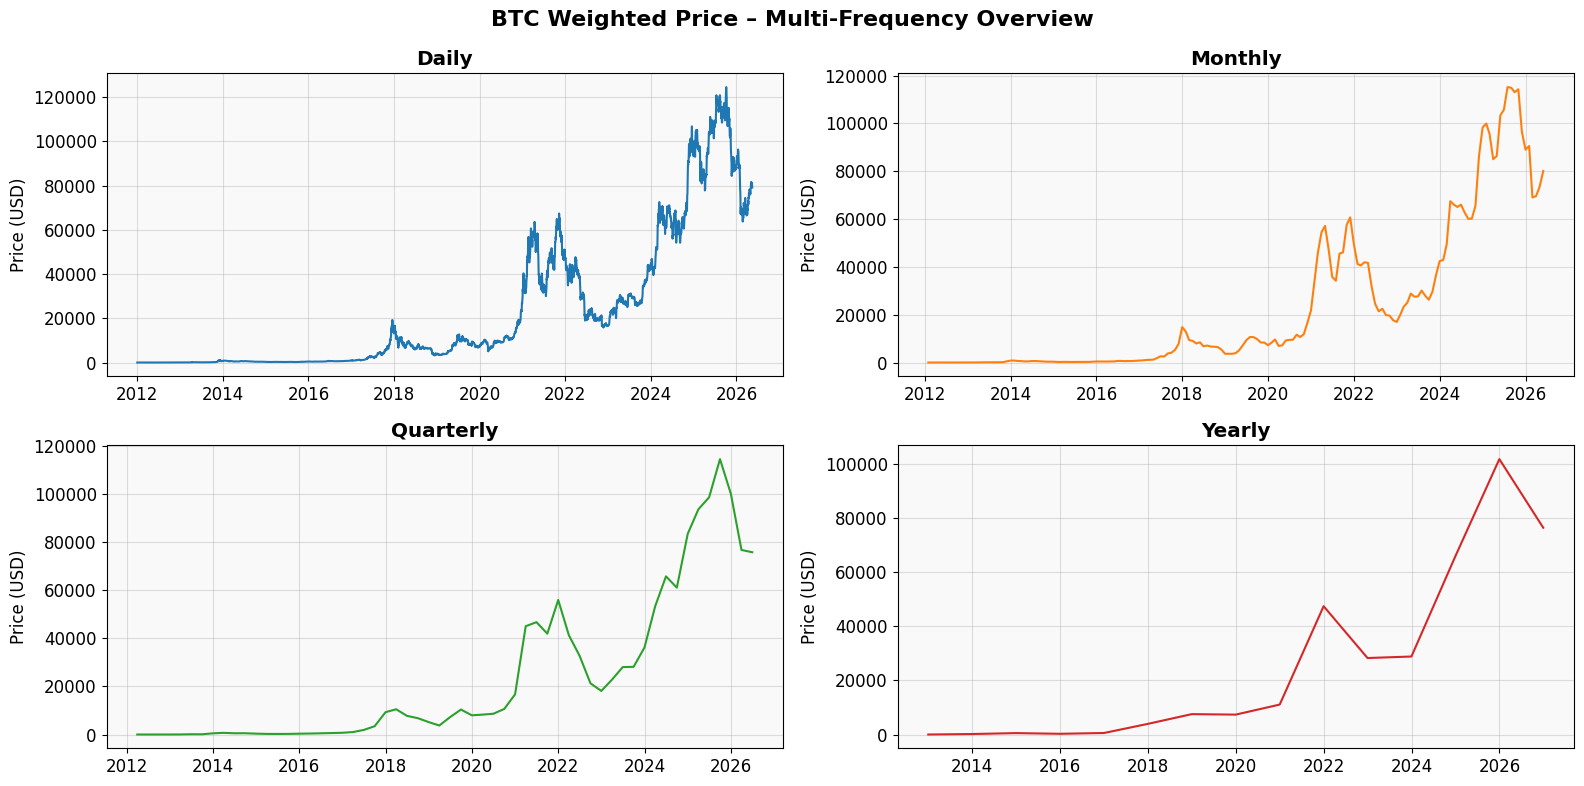

📊 Saved → btc_overview.png


In [54]:
def plot_multi_frequency(df_daily, df_monthly, df_quarterly, df_yearly):
    """
    2×2 grid showing BTC Weighted Price at four time resolutions.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    fig.suptitle('BTC Weighted Price – Multi-Frequency Overview', fontsize=16, fontweight='bold')

    pairs = [
        (axes[0, 0], df_daily,     'Daily',     '#1f77b4'),
        (axes[0, 1], df_monthly,   'Monthly',   '#ff7f0e'),
        (axes[1, 0], df_quarterly, 'Quarterly', '#2ca02c'),
        (axes[1, 1], df_yearly,    'Yearly',    '#d62728'),
    ]

    for ax, data, title, color in pairs:
        ax.plot(data['Weighted_Price'], color=color, linewidth=1.5)
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel('Price (USD)')
        ax.set_xlabel('')

    plt.tight_layout()
    plt.savefig('btc_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('📊 Saved → btc_overview.png')


plot_multi_frequency(df_daily, df_monthly, df_quarterly, df_yearly)

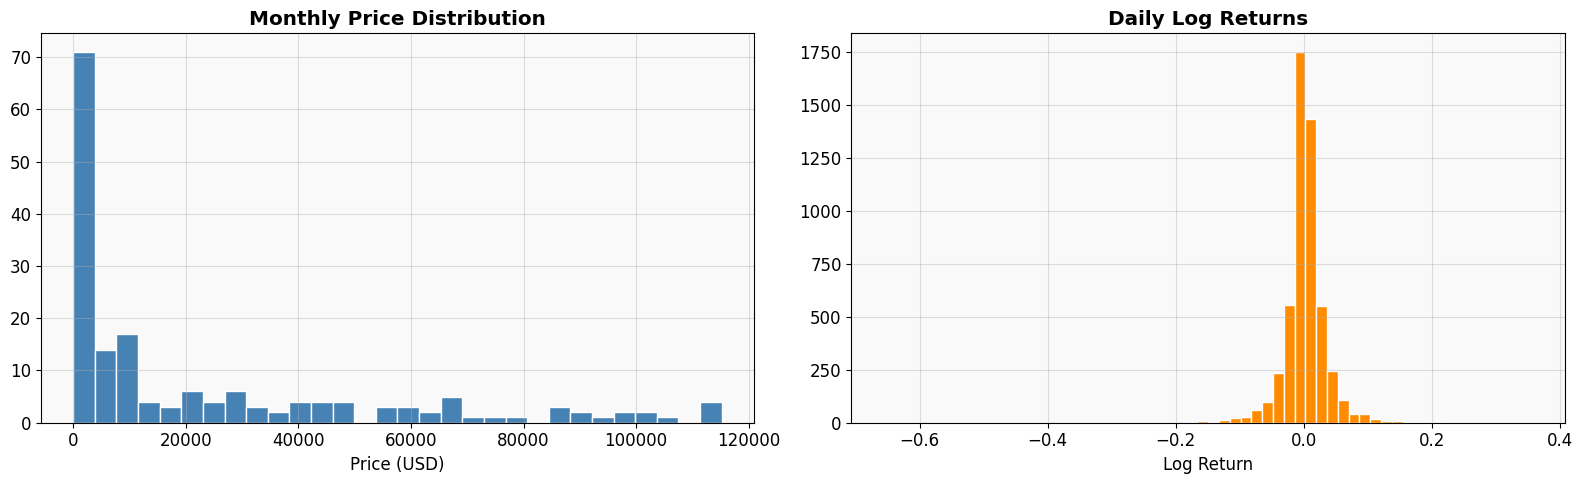

In [53]:

# Distribution + log-return histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_monthly['Weighted_Price'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Monthly Price Distribution', fontweight='bold')
axes[0].set_xlabel('Price (USD)')

log_ret = np.log(df_daily['Weighted_Price'] / df_daily['Weighted_Price'].shift(1)).dropna()
axes[1].hist(log_ret, bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Daily Log Returns', fontweight='bold')
axes[1].set_xlabel('Log Return')

plt.tight_layout()
plt.show()

---
## 5. Stationarity – Box-Cox & Differencing

In [35]:
def apply_boxcox(df_monthly):
    """
    Apply Box-Cox transformation and first-order differencing
    to stabilise variance and remove trend.
    """
    df_monthly = df_monthly.copy()

    df_monthly['Weighted_Price_box'], lmbda = stats.boxcox(
        df_monthly['Weighted_Price'].dropna()
    )

    df_monthly['diff'] = df_monthly['Weighted_Price_box'].diff()

    print(f'Box-Cox lambda (λ): {lmbda:.4f}')
    return df_monthly, lmbda


df_monthly, lmbda = apply_boxcox(df_monthly)

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(df_monthly['Weighted_Price'], color='steelblue')
axes[0].set_title('Original', fontweight='bold')

axes[1].plot(df_monthly['Weighted_Price_box'], color='darkorange')
axes[1].set_title('Box-Cox Transformed', fontweight='bold')

axes[2].plot(df_monthly['diff'], color='green')
axes[2].set_title('1st Difference (Box-Cox)', fontweight='bold')

plt.tight_layout()
plt.show()

Box-Cox lambda (λ): 0.1497


---
## 6. SARIMAX Model Selection & Forecasting

In [36]:
def select_model(df_monthly):
    """
    Grid-search over SARIMAX (p,1,q)(P,1,Q,12) parameters
    and return the model with the lowest AIC.
    """
    parameters = list(product(range(2), range(2), range(2), range(2)))

    best_aic   = np.inf
    best_model = None
    best_order = None
    results    = []

    print(f'Evaluating {len(parameters)} parameter combinations …')

    for p, q, P, Q in parameters:
        try:
            model = sm.tsa.statespace.SARIMAX(
                df_monthly['Weighted_Price_box'],
                order=(p, 1, q),
                seasonal_order=(P, 1, Q, 12)
            ).fit(disp=False)

            results.append({'Order': (p,1,q), 'Seasonal': (P,1,Q,12), 'AIC': model.aic})

            if model.aic < best_aic:
                best_aic   = model.aic
                best_model = model
                best_order = ((p,1,q), (P,1,Q,12))
        except:
            continue

    print(f'\n✅ Best Order       : {best_order[0]}')
    print(f'   Best Seasonal    : {best_order[1]}')
    print(f'   Best AIC         : {best_aic:.2f}')

    # Top 5 table
    results_df = pd.DataFrame(results).sort_values('AIC').head(5)
    display(results_df)

    return best_model


best_model = select_model(df_monthly)

Evaluating 16 parameter combinations …

✅ Best Order       : (0, 1, 1)
   Best Seasonal    : (0, 1, 1, 12)
   Best AIC         : 349.01


,Order,Seasonal,AIC
5,"(0, 1, 1)","(0, 1, 1, 12)",349.006531
9,"(1, 1, 0)","(0, 1, 1, 12)",349.111601
13,"(1, 1, 1)","(0, 1, 1, 12)",349.751495
7,"(0, 1, 1)","(1, 1, 1, 12)",350.487855
11,"(1, 1, 0)","(1, 1, 1, 12)",350.921261


In [37]:
def inverse_boxcox(y, lmbda):
    return np.exp(np.log(lmbda * y + 1) / lmbda)


def forecast_and_plot(df_monthly, model, lmbda):
    """
    Generate in-sample forecast, back-transform from Box-Cox space,
    and plot actual vs forecast.
    """
    df_out = df_monthly[['Weighted_Price']].copy()

    preds = model.predict(start=0, end=len(df_monthly) - 1)
    df_out['Forecast'] = inverse_boxcox(preds, lmbda)

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(df_out['Weighted_Price'], label='Actual',   color='steelblue',  linewidth=2)
    ax.plot(df_out['Forecast'],       label='Forecast', color='crimson',    linewidth=1.5, linestyle='--')
    ax.set_title('SARIMAX Forecast vs Actual – Monthly BTC Price', fontweight='bold', fontsize=14)
    ax.set_ylabel('Price (USD)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('btc_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('📊 Saved → btc_forecast.png')

    return df_out


df_forecast = forecast_and_plot(df_monthly, best_model, lmbda)

📊 Saved → btc_forecast.png


---
## 7. Regression Metrics

In [38]:
def calculate_metrics(actual, forecast):
    valid = actual.notna() & forecast.notna()

    mae  = mean_absolute_error(actual[valid], forecast[valid])
    rmse = np.sqrt(mean_squared_error(actual[valid], forecast[valid]))
    r2   = r2_score(actual[valid], forecast[valid])
    mape = np.mean(np.abs((actual[valid] - forecast[valid]) / actual[valid])) * 100

    metrics = pd.DataFrame({
        'Metric': ['MAE', 'RMSE', 'R²', 'MAPE (%)'],
        'Value' : [mae, rmse, r2, mape]
    })
    display(metrics.style.format({'Value': '{:.4f}'}).hide(axis='index'))


calculate_metrics(df_monthly['Weighted_Price'], df_forecast['Forecast'])

Metric,Value
MAE,2453.7126
RMSE,4904.4747
R²,0.9753
MAPE (%),15.7724


---
## 8. Feature Engineering for Machine Learning

In [39]:
def build_ml_features(df_monthly):
    """
    Create financial features suitable for clustering:
    - Return         : monthly pct change
    - Volatility     : 3-month rolling std of returns
    - Momentum       : raw price change
    - Log_Price      : log of weighted price (scale normalisation)
    - Price_Range    : (High – Low) proxy via rolling std of price
    """
    df_ml = df_monthly.copy()

    df_ml['Return']      = df_ml['Weighted_Price'].pct_change()
    df_ml['Volatility']  = df_ml['Return'].rolling(3).std()
    df_ml['Momentum']    = df_ml['Weighted_Price'].diff()
    df_ml['Log_Price']   = np.log1p(df_ml['Weighted_Price'])
    df_ml['Price_Range'] = df_ml['Weighted_Price'].rolling(3).std()

    df_ml.dropna(inplace=True)

    print(f'Feature matrix: {df_ml.shape[0]} rows × {df_ml.shape[1]} columns')
    return df_ml


df_ml = build_ml_features(df_monthly)
df_ml[['Weighted_Price','Return','Volatility','Momentum','Log_Price','Price_Range']].describe().round(4)

Feature matrix: 170 rows × 13 columns


,Weighted_Price,Return,Volatility,Momentum,Log_Price,Price_Range
count,170.0000,170.0000,170.0000,170.0000,170.0000,170.0000
mean,23660.3140,0.0861,0.1638,471.2024,8.3204,2429.2276
std,31389.8075,0.2929,0.1851,4830.4004,2.5996,3532.6322
min,4.9803,-0.3206,0.0059,-21524.1625,1.7885,0.0448
25%,525.6475,-0.0545,0.0801,-147.4908,6.2664,64.0965
50%,8330.2585,0.0216,0.1277,21.5067,9.0278,811.5417
75%,39559.6257,0.1611,0.1779,1179.3425,10.5845,3110.0185
max,115184.7420,2.4243,1.2758,20753.2046,11.6543,16583.2991


---
## 9. KMeans Clustering – Market Regime Detection

In [40]:
# ── 9a. Elbow Method ──────────────────────────────────────────────────────────

FEATURE_COLS = ['Weighted_Price', 'Return', 'Volatility', 'Momentum', 'Log_Price', 'Price_Range']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ml[FEATURE_COLS])

inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method – Inertia vs K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), sil_scores, 's-', color='darkorange', linewidth=2)
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()
print('Optimal K is where Elbow bends AND silhouette is highest.')

Optimal K is where Elbow bends AND silhouette is highest.


In [41]:
# ── 9b. Fit Final KMeans ──────────────────────────────────────────────────────

K_BEST = 3   # ← adjust based on elbow / silhouette above

kmeans = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
df_ml['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

sil  = silhouette_score(X_scaled, df_ml['KMeans_Cluster'])
db   = davies_bouldin_score(X_scaled, df_ml['KMeans_Cluster'])
ch   = calinski_harabasz_score(X_scaled, df_ml['KMeans_Cluster'])

print(f'KMeans (K={K_BEST}) Evaluation:')
print(f'  Silhouette Score      : {sil:.4f}  (higher = better, max 1)')
print(f'  Davies–Bouldin Index  : {db:.4f}  (lower  = better, min 0)')
print(f'  Calinski–Harabasz     : {ch:.2f} (higher = better)')

KMeans (K=3) Evaluation:
  Silhouette Score      : 0.4144  (higher = better, max 1)
  Davies–Bouldin Index  : 1.1074  (lower  = better, min 0)
  Calinski–Harabasz     : 67.11 (higher = better)


In [42]:
# ── 9c. Cluster Profiles ──────────────────────────────────────────────────────

profile = df_ml.groupby('KMeans_Cluster')[FEATURE_COLS].mean().round(2)
profile.index = [f'Cluster {i}' for i in profile.index]

# Label clusters by price level
regime_map = profile['Weighted_Price'].rank().astype(int).map({1:'Bear 🐻', 2:'Neutral ⚖️', 3:'Bull 🐂'})
profile['Regime'] = regime_map

display(profile)

,Weighted_Price,Return,Volatility,Momentum,Log_Price,Price_Range,Regime
Cluster 0,7000.85,0.05,0.14,159.93,7.36,665.73,Neutral ⚖️
Cluster 1,1931.51,0.76,0.75,870.71,5.66,643.67,Bear 🐻
Cluster 2,65730.10,0.04,0.12,1109.31,11.00,6788.05,Bull 🐂


In [43]:
# ── 9d. Visualise KMeans – Timeline + PCA ────────────────────────────────────

palette = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71'}  # red / blue / green
colors  = df_ml['KMeans_Cluster'].map(palette)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('KMeans Market Regime Clustering', fontsize=15, fontweight='bold')

# Timeline
axes[0].scatter(df_ml.index, df_ml['Weighted_Price'], c=colors, s=40, alpha=0.85, edgecolors='white', linewidth=0.3)
axes[0].set_title('BTC Price Timeline – Coloured by Cluster', fontweight='bold')
axes[0].set_ylabel('Price (USD)')
patches = [mpatches.Patch(color=palette[i], label=f'Cluster {i}') for i in range(K_BEST)]
axes[0].legend(handles=patches)

# PCA scatter
for c in range(K_BEST):
    mask = df_ml['KMeans_Cluster'] == c
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {c}',
                    color=palette[c], s=50, alpha=0.8, edgecolors='white', linewidth=0.3)

axes[1].set_title('PCA Projection of Clusters', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].legend()

plt.tight_layout()
plt.savefig('btc_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved → btc_kmeans_clusters.png')

📊 Saved → btc_kmeans_clusters.png


---
## 10. DBSCAN Clustering – Anomaly & Density Detection

In [44]:
# ── 10a. Epsilon Tuning via k-distance plot ───────────────────────────────────
from sklearn.neighbors import NearestNeighbors

k = 5
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(distances[:, k-1])[::-1]

plt.figure(figsize=(12, 4))
plt.plot(k_dist, color='purple', linewidth=1.5)
plt.axhline(y=0.7, color='red', linestyle='--', label='ε candidate = 0.7')
plt.title('k-Distance Graph (k=5) – Choose ε at the "Elbow"', fontweight='bold')
plt.xlabel('Points (sorted)')
plt.ylabel(f'{k}-NN Distance')
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
# ── 10b. Fit DBSCAN ───────────────────────────────────────────────────────────

EPS        = 0.7   # ← tune from k-distance plot above
MIN_SAMPLES = 5

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
df_ml['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

n_clusters  = len(set(df_ml['DBSCAN_Cluster'])) - (1 if -1 in df_ml['DBSCAN_Cluster'].values else 0)
n_noise     = (df_ml['DBSCAN_Cluster'] == -1).sum()
n_total     = len(df_ml)

print(f'DBSCAN Results (ε={EPS}, min_samples={MIN_SAMPLES}):')
print(f'  Clusters found   : {n_clusters}')
print(f'  Noise points (−1): {n_noise} / {n_total}  ({n_noise/n_total*100:.1f}%)')

display(df_ml['DBSCAN_Cluster'].value_counts().rename_axis('Cluster').reset_index(name='Count'))

DBSCAN Results (ε=0.7, min_samples=5):
  Clusters found   : 2
  Noise points (−1): 63 / 170  (37.1%)


,Cluster,Count
0,1,97
1,-1,63
2,0,10


In [46]:
# ── 10c. Visualise DBSCAN – Timeline + PCA ────────────────────────────────────

unique_labels = sorted(df_ml['DBSCAN_Cluster'].unique())
cmap = cm.get_cmap('tab10', len(unique_labels))
label_to_color = {lbl: ('#808080' if lbl == -1 else cmap(i)) for i, lbl in enumerate(unique_labels)}
db_colors = df_ml['DBSCAN_Cluster'].map(label_to_color)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('DBSCAN Density Clustering', fontsize=15, fontweight='bold')

# Timeline
axes[0].scatter(df_ml.index, df_ml['Weighted_Price'], c=db_colors, s=40, alpha=0.85,
                edgecolors='white', linewidth=0.3)
axes[0].set_title('BTC Price Timeline – DBSCAN Clusters', fontweight='bold')
axes[0].set_ylabel('Price (USD)')
patches = [
    mpatches.Patch(color=label_to_color[lbl], label=('Noise' if lbl == -1 else f'Cluster {lbl}'))
    for lbl in unique_labels
]
axes[0].legend(handles=patches, fontsize=9)

# PCA
for lbl in unique_labels:
    mask = df_ml['DBSCAN_Cluster'] == lbl
    label_name = 'Noise ⚠️' if lbl == -1 else f'Cluster {lbl}'
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], label=label_name,
                    color=label_to_color[lbl], s=50, alpha=0.8,
                    edgecolors='white', linewidth=0.3,
                    marker='x' if lbl == -1 else 'o')

axes[1].set_title('PCA Projection – DBSCAN Clusters + Noise', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('btc_dbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved → btc_dbscan_clusters.png')

📊 Saved → btc_dbscan_clusters.png


In [47]:
# ── 10d. Anomaly Inspection ───────────────────────────────────────────────────

anomalies = df_ml[df_ml['DBSCAN_Cluster'] == -1][['Weighted_Price', 'Return', 'Volatility', 'Momentum']]
print(f'\nAnomalous months detected by DBSCAN: {len(anomalies)}')
display(anomalies.round(4))


Anomalous months detected by DBSCAN: 63


,Weighted_Price,Return,Volatility,Momentum
Date,,,,
2013-02-28,25.7071,0.6845,0.3022,10.4460
2013-03-31,56.7089,1.2060,0.5226,31.0018
2013-04-30,127.2081,1.2432,0.3124,70.4993
2013-05-31,117.8420,-0.0736,0.7497,-9.3662
2013-06-30,105.7258,-0.1028,0.7688,-12.1162
...,...,...,...,...
2026-01-31,90559.2359,0.0174,0.0865,1548.7752
2026-02-28,69035.0734,-0.2377,0.1289,-21524.1625
2026-03-31,69618.0331,0.0084,0.1448,582.9597


---
## 11. KMeans vs DBSCAN – Side-by-Side Comparison

In [48]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('KMeans vs DBSCAN – Market Regime Timeline', fontsize=14, fontweight='bold')

# KMeans
axes[0].scatter(df_ml.index, df_ml['Weighted_Price'],
                c=df_ml['KMeans_Cluster'].map(palette), s=30, alpha=0.85,
                edgecolors='white', linewidth=0.2)
axes[0].set_title(f'KMeans (K={K_BEST})', fontweight='bold')
axes[0].set_ylabel('Price (USD)')
patches_km = [mpatches.Patch(color=palette[i], label=f'Cluster {i}') for i in range(K_BEST)]
axes[0].legend(handles=patches_km)

# DBSCAN
axes[1].scatter(df_ml.index, df_ml['Weighted_Price'],
                c=db_colors, s=30, alpha=0.85,
                edgecolors='white', linewidth=0.2)
axes[1].set_title(f'DBSCAN (ε={EPS}, min_samples={MIN_SAMPLES})', fontweight='bold')
axes[1].set_ylabel('Price (USD)')
axes[1].legend(handles=patches, fontsize=9)

plt.tight_layout()
plt.savefig('btc_clusters_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved → btc_clusters_comparison.png')

📊 Saved → btc_clusters_comparison.png


---
## 12. Clustering Evaluation Summary

In [49]:
# KMeans scores already computed above
# DBSCAN silhouette only valid when >1 non-noise cluster exists
valid_db = df_ml[df_ml['DBSCAN_Cluster'] != -1]
X_valid  = X_scaled[df_ml['DBSCAN_Cluster'] != -1]

if len(valid_db['DBSCAN_Cluster'].unique()) > 1:
    db_sil = silhouette_score(X_valid, valid_db['DBSCAN_Cluster'])
    db_dbi = davies_bouldin_score(X_valid, valid_db['DBSCAN_Cluster'])
else:
    db_sil = db_dbi = float('nan')

summary = pd.DataFrame({
    'Algorithm'        : ['KMeans', 'DBSCAN'],
    'Clusters'         : [K_BEST, n_clusters],
    'Noise Points'     : [0, n_noise],
    'Silhouette ↑'     : [round(sil,4), round(db_sil,4)],
    'Davies–Bouldin ↓' : [round(db,4), round(db_dbi,4)],
})

display(summary.set_index('Algorithm'))

print('''
Interpretation:
  KMeans  – partitions every point; good for equally-sized, spherical regimes.
  DBSCAN  – identifies dense regions and labels outliers as noise (−1),
             making it ideal for detecting unusual market conditions.
''')

,Clusters,Noise Points,Silhouette ↑,Davies–Bouldin ↓
Algorithm,,,,
KMeans,3,0,0.4144,1.1074
DBSCAN,2,63,0.3956,0.7071



Interpretation:
  KMeans  – partitions every point; good for equally-sized, spherical regimes.
  DBSCAN  – identifies dense regions and labels outliers as noise (−1),
             making it ideal for detecting unusual market conditions.



---
## 13. Save Results

In [50]:
# Save final dataframe with cluster labels
df_ml.to_csv('btc_clustered.csv')

# Save models
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open('dbscan_model.pkl', 'wb') as f:
    pickle.dump(dbscan, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('✅ Saved:')
print('  btc_clustered.csv   – data with cluster labels')
print('  kmeans_model.pkl    – fitted KMeans model')
print('  dbscan_model.pkl    – fitted DBSCAN model')
print('  scaler.pkl          – StandardScaler')

✅ Saved:
  btc_clustered.csv   – data with cluster labels
  kmeans_model.pkl    – fitted KMeans model
  dbscan_model.pkl    – fitted DBSCAN model
  scaler.pkl          – StandardScaler


---
## 14. Key Takeaways

| Topic | Finding |
|---|---|
| **Forecasting** | SARIMAX captures the long-run trend; Box-Cox stabilises variance before modelling |
| **KMeans** | Segments the market into K distinct price-level regimes (Bear / Neutral / Bull) |
| **DBSCAN** | Discovers dense clusters without pre-specifying K; flags anomalous months as noise |
| **PCA** | Compresses 6 features to 2D for interpretable visualisation of cluster separation |
| **Evaluation** | Silhouette score and Davies–Bouldin index quantify cluster compactness and separation |

> **Next steps:** Try HDBSCAN for improved robustness, add on-chain features, or feed cluster labels as regime indicators into a downstream supervised model.